## Climate Zones - Data Exploration
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-02-10
* © British Crown Copyright 2017-2065, Met Office. Please see LICENSE.md for license details.

Author - Stephen Haddad


## Overview of the broad topic covered


The climate of different areas of the world is classified into different types, based on the Koppen-Geiger scheme. As the climate changes, some areas may change the classification of their climate 
In this series of tutorial notebooks, we willlearn how to build a machine learning pipeline by building a model to predict the clinate zone of a location from key climate means and indicators. We will look at how climate models predict shifts in the classification of climate zones as the climate changes in the future.

Links
 - [CLimate Zones Dataset](https://www.gloh2o.org/koppen/#:~:text=The%20K%C3%B6ppen%2DGeiger%20climate%20classification%20maps%20are%20high%2Dresolution,Climate%20Sensitivity%20(ECS)%2C%20and%20historical%20warming%20trend) 
    

### Prerequisites 
what background information is needed to go through the notebook


### Learning outcomes from completing the notebook

## Tutorial 
a balance of explanation and activity



In [1]:
import pathlib
import os

In [2]:
import matplotlib.pyplot
import cartopy.crs

In [23]:
import xarray

#### Dataset parameters

In [4]:
root_data_dir = pathlib.Path(os.environ['DATADIR']) / 'climate_zones'
print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/data/users/stephen.haddad/climate_zones')

In [63]:
resolutions_dict = {
    0.1: '0p1',
    0.5: '0p5',
    1.0: '1p0',
}

dataset_prefix_dict = {
    'climate_mean': 'ensemble_mean',
    'climate_std': 'ensemble_std',
    'climate_zone': 'koppen_geiger',
    
}
format_str = 'nc'
historic_scenario_str = 'historic'

future_scenario_list = ['ssp119','ssp126','ssp245','ssp370','ssp434','ssp460','ssp585']
historic_scenario_list = [historic_scenario_str,]

time_periods = { 
    (1901,1930): historic_scenario_list, 
    (1931,1960): historic_scenario_list,
    (1961,1990): historic_scenario_list,
    (1991,2020): historic_scenario_list,
    (2041,2070): future_scenario_list,
    (2071,2099): future_scenario_list,
}


In [6]:
fname_template = '{prefix}_{res}.{suffix}'
time_dir_template = '{start_year}_{end_year}'

### Load the data

In [64]:
def get_data_path(root_dir, time_period, scenario_id, prefix, resolution, suffix) :
    start_year = time_period[0]
    end_year = time_period[1]
    if scenario_id == historic_scenario_str:
        data_dir = root_data_dir / time_dir_template.format(start_year=start_year,end_year=end_year)
    else:
        data_dir = root_data_dir / time_dir_template.format(start_year=start_year,end_year=end_year) / scenario_id 
    data_fname = fname_template.format(prefix=prefix, 
                                       res=resolutions_dict[current_res], 
                                       suffix=format_str)
    return data_dir / data_fname

In [57]:
current_res = 1.0

In [58]:
data_path_dict = {
    (start_year, end_year): {
        scenario_id: { ds_id: get_data_path(root_dir=root_data_dir,
                                            time_period=(start_year, end_year),
                                            scenario_id=scenario_id, 
                                            prefix=ds_str,
                                            resolution=current_res,
                                            suffix=format_str,
                                           )
                       for ds_id, ds_str in dataset_prefix_dict.items()
                     } 
        for scenario_id in current_scenarios
    }
    for (start_year, end_year), current_scenarios in time_periods.items()                                                                                                             
}

In [59]:
for cp, ps in data_path_dict.items():
    for sid, pd in ps.items():
        for ds_id, ds_path in pd.items():
            print(cp, ds_id, ds_path.is_file())
data_path_dict

(1901, 1930) climate_mean True
(1901, 1930) climate_std True
(1901, 1930) climate_zone True
(1931, 1960) climate_mean True
(1931, 1960) climate_std True
(1931, 1960) climate_zone True
(1961, 1990) climate_mean True
(1961, 1990) climate_std True
(1961, 1990) climate_zone True
(1991, 2020) climate_mean True
(1991, 2020) climate_std True
(1991, 2020) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climat

{(1901,
  1930): {'historic': {'climate_mean': PosixPath('/data/users/stephen.haddad/climate_zones/1901_1930/ensemble_mean_1p0.nc'),
   'climate_std': PosixPath('/data/users/stephen.haddad/climate_zones/1901_1930/ensemble_std_1p0.nc'),
   'climate_zone': PosixPath('/data/users/stephen.haddad/climate_zones/1901_1930/koppen_geiger_1p0.nc')}},
 (1931,
  1960): {'historic': {'climate_mean': PosixPath('/data/users/stephen.haddad/climate_zones/1931_1960/ensemble_mean_1p0.nc'),
   'climate_std': PosixPath('/data/users/stephen.haddad/climate_zones/1931_1960/ensemble_std_1p0.nc'),
   'climate_zone': PosixPath('/data/users/stephen.haddad/climate_zones/1931_1960/koppen_geiger_1p0.nc')}},
 (1961,
  1990): {'historic': {'climate_mean': PosixPath('/data/users/stephen.haddad/climate_zones/1961_1990/ensemble_mean_1p0.nc'),
   'climate_std': PosixPath('/data/users/stephen.haddad/climate_zones/1961_1990/ensemble_std_1p0.nc'),
   'climate_zone': PosixPath('/data/users/stephen.haddad/climate_zones/1961_19

We'll start by loading the three parts to the data for the historical period 1901 to 1930.

In [62]:
data_dict = {
    current_period: {
        scenario_id: {ds_id: xarray.open_dataset(current_path) for ds_id, current_path in ds_dict.items()} for scenario_id, ds_dict in data_path_dict[current_period].items()
    } for current_period in [(1901,1930), (2071,2099)]
}

In [71]:
data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_mean'].loc[{'time':1.0}]

<xarray.Dataset> Size: 523kB
Dimensions:          (lat: 180, lon: 360)
Coordinates:
  * lat              (lat) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon              (lon) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
    time             float64 8B 1.0
Data variables:
    precipitation    (lat, lon) float32 259kB ...
    air_temperature  (lat, lon) float32 259kB ...
Attributes:
    history:  Created on 2025-10-21 05:47

In [82]:
data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_zone']

<xarray.Dataset> Size: 523kB
Dimensions:        (lat: 180, lon: 360)
Coordinates:
  * lat            (lat) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon            (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    kg_class       (lat, lon) float32 259kB ...
    kg_confidence  (lat, lon) float32 259kB ...
Attributes:
    history:  Created on 2025-10-21 06:26

Text(0.5, 1.0, 'KG CLimate Zones (1901, 1930)')

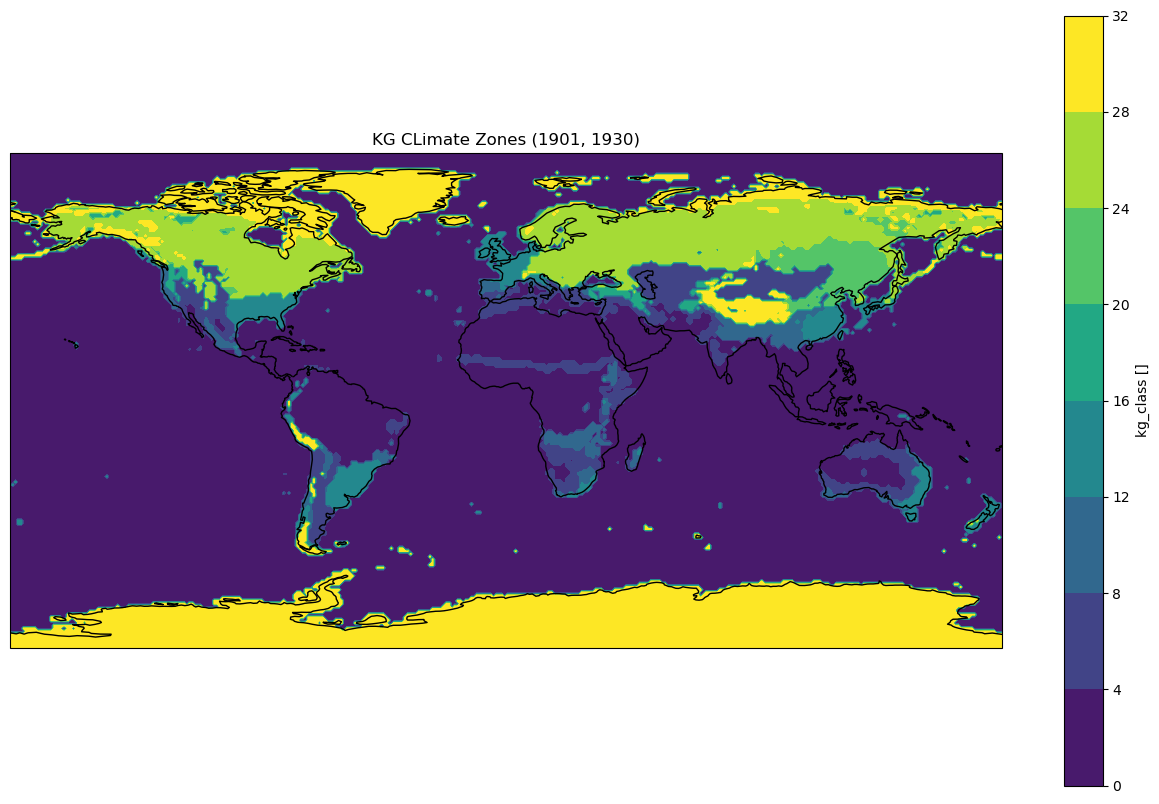

In [86]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))

ax1 = fig1.add_subplot(1,1,1 ,projection=cartopy.crs.PlateCarree(),)
plot_ds = data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_zone']['kg_class']
plot_ds.plot.contourf(ax=ax1, transform=cartopy.crs.PlateCarree()) 
ax1.coastlines()
ax1.set_title(f'KG CLimate Zones {list(time_periods.keys())[0]}')

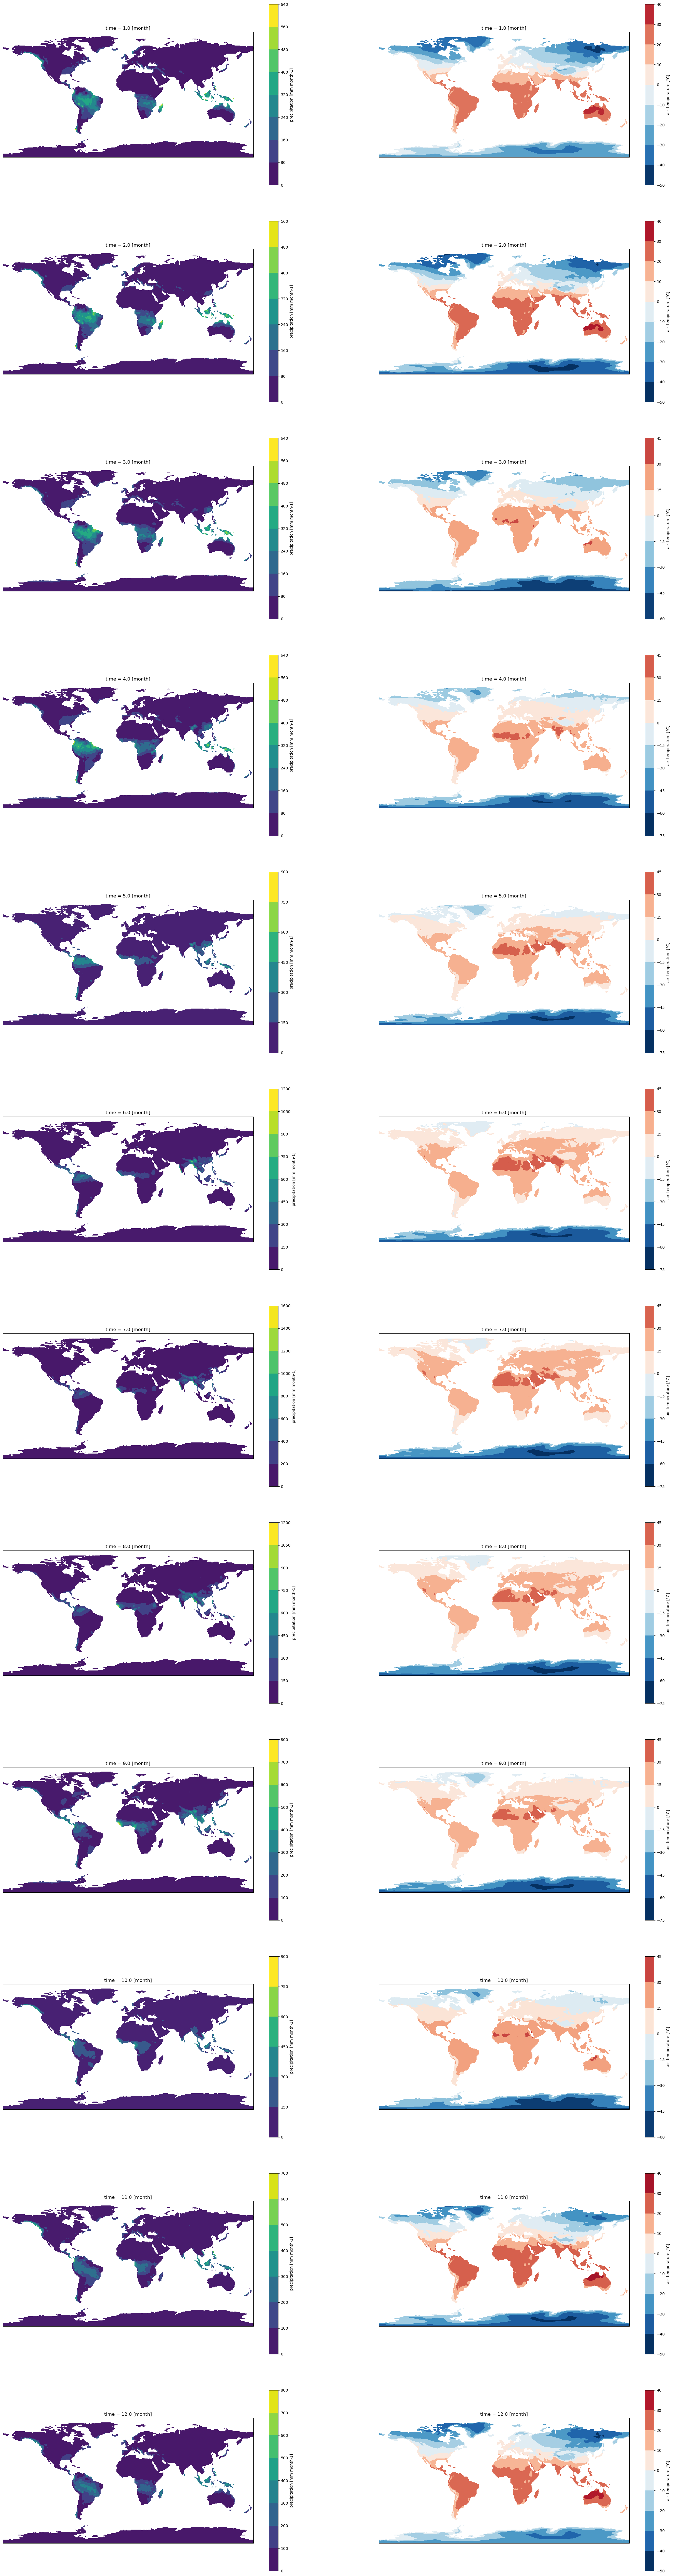

In [81]:
fig1 = matplotlib.pyplot.figure(figsize=(3*16,12*10))

for month in range(12):
    ax1 = fig1.add_subplot(12,2,month*2 +1 ,projection=cartopy.crs.PlateCarree())
    plot_ds = data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_mean'].loc[{'time': month+1}]['precipitation']
    plot_ds.plot.contourf(ax=ax1, transform=cartopy.crs.PlateCarree()) 

    ax1 = fig1.add_subplot(12,2,month*2 +2 ,projection=cartopy.crs.PlateCarree())
    plot_ds = data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_mean'].loc[{'time': month+1}]['air_temperature']
    plot_ds.plot.contourf(ax=ax1, transform=cartopy.crs.PlateCarree()) 


In [90]:
# data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_zone']['kg_class']

data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_mean'].to_pandas()


ValueError: cannot convert Datasets with 3 dimensions into pandas objects without changing the number of dimensions. Please use Dataset.to_dataframe() instead.

## Exercises
for students to try that do not have solutions but maybe have an answer or benchmark to facilitate understanding


### Next steps or potential follow on material



###  Exmaples of Use


### Data statement
###     References
